## 1- problem Definition and understanding¶
With growing demands and cut-throat competitions in the market, a Superstore Giant is seeking your knowledge in understanding what works best for them. They would like to understand which products, regions, categories and customer segments they should target or avoid

Dataset: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final

## 1-1 Asking questions¶


- What are the top selling products in the superstore?

- What is the sales trend over time (monthly, yearly)?

- Which category of products generates the highest revenue and profit?

- Which region generates the most sales?

- What is the impact of discounts and promotions on sales?

- What is the average profit margin for each product category?

- Which sub-category of products has the highest demand?

## 2- Data understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings ## used to ignore warnings
warnings.filterwarnings('ignore')

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/superstore-dataset-final/Sample - Superstore.csv


In [3]:
data =pd.read_csv('/kaggle/input/superstore-dataset-final/Sample - Superstore.csv',encoding='windows-1252')

In [4]:
# Set the maximum number of columns to display
pd.options.display.max_columns = None

# Set the maximum number of rows to display
pd.options.display.max_rows = None

In [5]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
data.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,California,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [8]:
data['Segment'].unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

## Description of each column

* Row ID => Unique ID for each row.
* Order ID => Unique Order ID for each Customer.
* Order Date => Order Date of the product.
* Ship Date => Shipping Date of the Product.
* Ship Mode=> Shipping Mode specified by the Customer.
* Customer ID => Unique ID to identify each Customer.
* Customer Name => Name of the Customer.
* Segment => The segment where the Customer belongs.
* Country => Country of residence of the Customer.
* City => City of residence of of the Customer.
* State => State of residence of the Customer.
* Postal Code => Postal Code of every Customer.
* Region => Region where the Customer belong.
* Product ID => Unique ID of the Product.
* Category => Category of the product ordered.
* Sub-Category => Sub-Category of the product ordered.
* Product Name => Name of the Product
* Sales => Sales of the Product.
* Quantity => Quantity of the Product.
* Discount => Discount provided.
* Profit => Profit/Loss incurred.

## Data wrangling

**checking missing values**

In [9]:
data.isna().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [10]:
data["Order Date"] = pd.to_datetime(data["Order Date"])

In [11]:
#data["Ship Date"] = pd.to_datetime(data["Ship Date"])

In [12]:
data['Order Date'].agg(['min','max'])

min   2014-01-03
max   2017-12-30
Name: Order Date, dtype: datetime64[ns]

In [13]:
#data.loc[data['Order Date']>'2017-12-30']

**some statistical information**

Understanding the distribution of the data: The mean, min, max, and other metrics provide a quick overview of the distribution of the data.

Outlier detection: The min, 25%, 75%, and max values can help identify outliers in the data.

Data normalization: The mean and std values can be used to normalize the data.

Feature scaling: The min, max, and other values can be used to scale the features to a suitable range.

In [14]:
data.describe()

,Row ID,Order Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [15]:
# what about duplication 
data.duplicated().sum()

0

**shown the number of unique values**

In [16]:
for f in data.columns:
    r=data[f].nunique()
    print(f'{f} : {r}')

Row ID : 9994
Order ID : 5009
Order Date : 1237
Ship Date : 1334
Ship Mode : 4
Customer ID : 793
Customer Name : 793
Segment : 3
Country : 1
City : 531
State : 49
Postal Code : 631
Region : 4
Product ID : 1862
Category : 3
Sub-Category : 17
Product Name : 1850
Sales : 5825
Quantity : 14
Discount : 12
Profit : 7287


## Exploratory Data Analysis - EDA

**1- What are the top selling products in the superstore?**

In [17]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [18]:
product_group=data.groupby(["Product Name"]).Sales.sum()
product_group.head()


Product Name
"While you Were Out" Message Book, One Form per Page     25.228
#10 Gummed Flap White Envelopes, 100/Box                 41.300
#10 Self-Seal White Envelopes                           108.682
#10 White Business Envelopes,4 1/8 x 9 1/2              488.904
#10- 4 1/8" x 9 1/2" Recycled Envelopes                 286.672
Name: Sales, dtype: float64

In [19]:
top_selling_products=product_group.sort_values(ascending=False)

In [20]:
top_5_selling_products=pd.DataFrame(top_selling_products.head())
top_5_selling_products

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479


Text(0, 0.5, 'total sales')

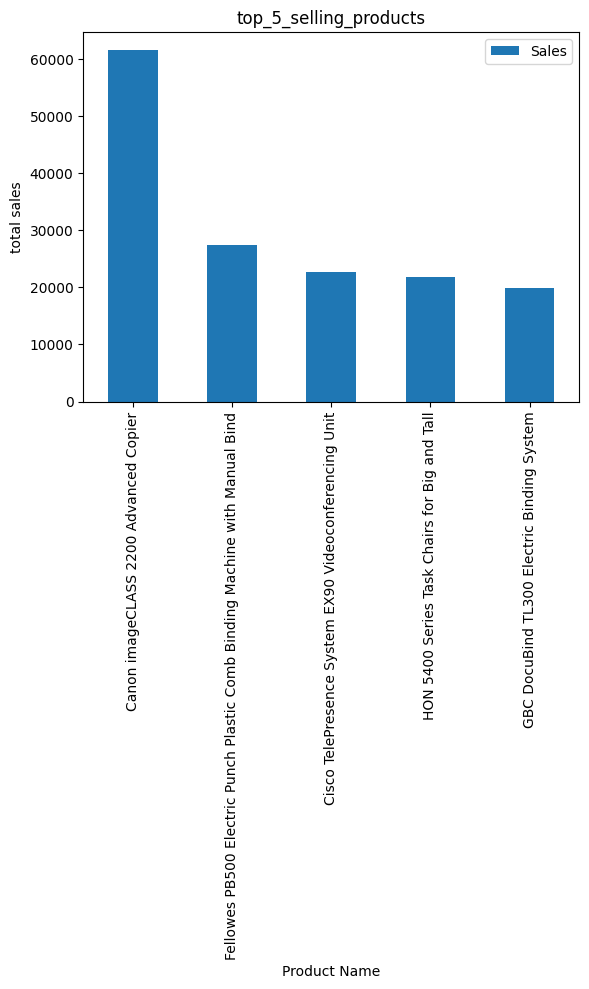

In [21]:
top_5_selling_products.plot(kind='bar')
plt.title('top_5_selling_products')
plt.xlabel('Product Name')
plt.ylabel('total sales')
#plt.show()

**top-profitable products ?**

In [22]:
product_group=data.groupby(["Product Name"]).Profit.sum()

In [23]:
top_profit_products=product_group.sort_values(ascending=False)


In [24]:
top_5_profit_products=pd.DataFrame(top_profit_products.head())
top_5_profit_products

,Profit
Product Name,
Canon imageCLASS 2200 Advanced Copier,25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,7753.0390
Hewlett Packard LaserJet 3310 Copier,6983.8836
Canon PC1060 Personal Laser Copier,4570.9347
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",4094.9766


Text(0, 0.5, 'total Profit')

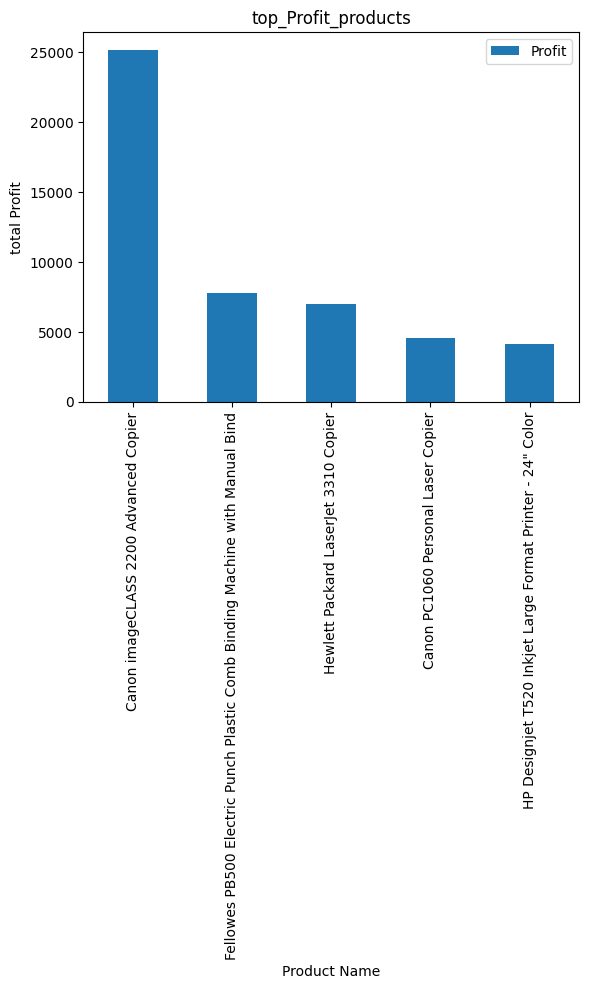

In [25]:
top_5_profit_products.plot(kind='bar')
plt.title('top_Profit_products')
plt.xlabel('Product Name')
plt.ylabel('total Profit')
#plt.show()

In [26]:
top_5_selling_products.index==top_5_profit_products.index

array([ True,  True, False, False, False])

## Now we can conclude some things
**top_5_selling_products:**
- Canon imageCLASS 2200 Advanced Copier
- Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind
- Cisco TelePresence System EX90 Videoconferencing Unit
- HON 5400 Series Task Chairs for Big and Tall
- GBC DocuBind TL300 Electric Binding System

**top_5_profit_products:**
- Canon imageCLASS 2200 Advanced Copier
- Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind
- Hewlett Packard LaserJet 3310 Copier
- Canon PC1060 Personal Laser Copier
- HP Designjet T520 Inkjet Large Format Printer - 24" Color

**The highest selling products, and the most profitable**
- Canon imageCLASS 2200 Advanced Copier
- Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind


# What is the sales trend over time (monthly, yearly)?

In [27]:
monthly_sales =data.groupby('Order Date').sum()
monthly_sales = monthly_sales.resample('M').sum()
monthly_sales.head()

,Row ID,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
Order Date,,,,,,,,,,,,,,,,,,,,
2014-01-31,346176,CA-2014-103800CA-2014-112326CA-2014-112326CA-2...,1/7/20141/8/20141/8/20141/8/20141/12/20141/8/2...,Standard ClassStandard ClassStandard ClassStan...,DP-13000PO-19195PO-19195PO-19195MB-18085LS-172...,Darren PowersPhillina OberPhillina OberPhillin...,ConsumerHome OfficeHome OfficeHome OfficeConsu...,United StatesUnited StatesUnited StatesUnited ...,HoustonNapervilleNapervilleNapervillePhiladelp...,TexasIllinoisIllinoisIllinoisPennsylvaniaCalif...,4342297,CentralCentralCentralCentralEastWestSouthSouth...,OFF-PA-10000174OFF-LA-10003223OFF-ST-10002743O...,Office SuppliesOffice SuppliesOffice SuppliesO...,PaperLabelsStorageBindersArtPaperArtChairsBind...,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",14236.895,284,10.00,2450.1907
2014-02-28,272235,CA-2014-140795CA-2014-139857CA-2014-123400CA-2...,2/3/20142/6/20142/9/20142/9/20142/6/20142/6/20...,First ClassStandard ClassStandard ClassStandar...,BD-11500CD-12790EB-13930EB-13930TB-21400TB-214...,Bradley DruckerCynthia DelaneyEric BarretoEric...,ConsumerHome OfficeConsumerConsumerConsumerCon...,United StatesUnited StatesUnited StatesUnited ...,Green BaySan DiegoSaint PetersburgSaint Peters...,WisconsinCaliforniaFloridaFloridaWashingtonWas...,3049775,CentralWestSouthSouthWestWestWestWestWestSouth...,TEC-AC-10001432OFF-FA-10001843OFF-BI-10000666T...,TechnologyOffice SuppliesOffice SuppliesTechno...,AccessoriesFastenersBindersPhonesBindersBinder...,Enermax Aurora Lite KeyboardStaplesSurelock Po...,4519.892,159,8.10,862.3084
2014-03-31,871575,CA-2014-104269US-2014-143707CA-2014-113880CA-2...,3/6/20143/5/20143/5/20143/5/20143/5/20143/5/20...,Second ClassStandard ClassStandard ClassStanda...,DB-13060HR-14770VF-21715VF-21715SC-20380SC-203...,Dave BrooksHallie RedmondVicky FreymannVicky F...,ConsumerHome OfficeHome OfficeHome OfficeConsu...,United StatesUnited StatesUnited StatesUnited ...,SeattleNew York CityElmhurstElmhurstEl PasoEl ...,WashingtonNew YorkIllinoisIllinoisTexasTexasTe...,8314538,WestEastCentralCentralCentralCentralCentralCen...,FUR-CH-10004063TEC-PH-10003655FUR-CH-10000863O...,FurnitureTechnologyFurnitureOffice SuppliesOff...,ChairsPhonesChairsPaperFastenersChairsFurnishi...,Global Deluxe High-Back Manager's ChairSannysi...,55691.009,585,26.30,498.7299
2014-04-30,690625,US-2014-157021US-2014-157021CA-2014-138359CA-2...,4/6/20144/6/20144/6/20144/6/20144/8/20144/8/20...,Second ClassSecond ClassStandard ClassStandard...,KM-16720KM-16720KH-16330KH-16330RD-19585RD-195...,Kunst MillerKunst MillerKatharine HarmsKathari...,ConsumerConsumerCorporateCorporateConsumerCons...,United StatesUnited StatesUnited StatesUnited ...,VallejoVallejoRevereRevereAthensAthensAthensHo...,CaliforniaCaliforniaMassachusettsMassachusetts...,7723827,WestWestEastEastSouthSouthSouthCentralCentralS...,OFF-LA-10002312OFF-BI-10000042OFF-ST-10000636O...,Office SuppliesOffice SuppliesOffice SuppliesO...,LabelsBindersStorageBindersPaperPhonesApplianc...,"Avery 490Pressboard Data Binder, Crimson, 12"" ...",28295.345,536,14.85,3488.8352
2014-05-31,611708,CA-2014-115056CA-2014-124618CA-2014-130274CA-2...,5/2/20145/4/20145/5/20145/10/20145/10/20145/8/...,Same DaySecond ClassFirst ClassStandard ClassS...,AR-10510CS-11860JS-15940NC-18415NC-18415PM-189...,Andrew RobertsCari SchnellingJoni SundaresamNa...,ConsumerConsumerHome OfficeConsumerConsumerCon...,United StatesUnited StatesUnited StatesUnited ...,ColumbusLakelandAppletonYonkersYonkersJacksonM...,OhioFloridaWisconsinNew YorkNew YorkMichiganCo...,6497804,EastSouthCentralEastEastCentralEastCentralCent...,OFF-AP-10003971TEC-CO-10004202OFF-LA-10002195O...,Office SuppliesTechnologyOffice SuppliesOffice...,AppliancesCopiersLabelsBindersBindersBindersFu...,Belkin 6 Outlet Metallic Surge StripBrother DC...,23648.287,466,18.95,2738.7096


Text(0.5, 1.0, 'Monthly Sales Trend')

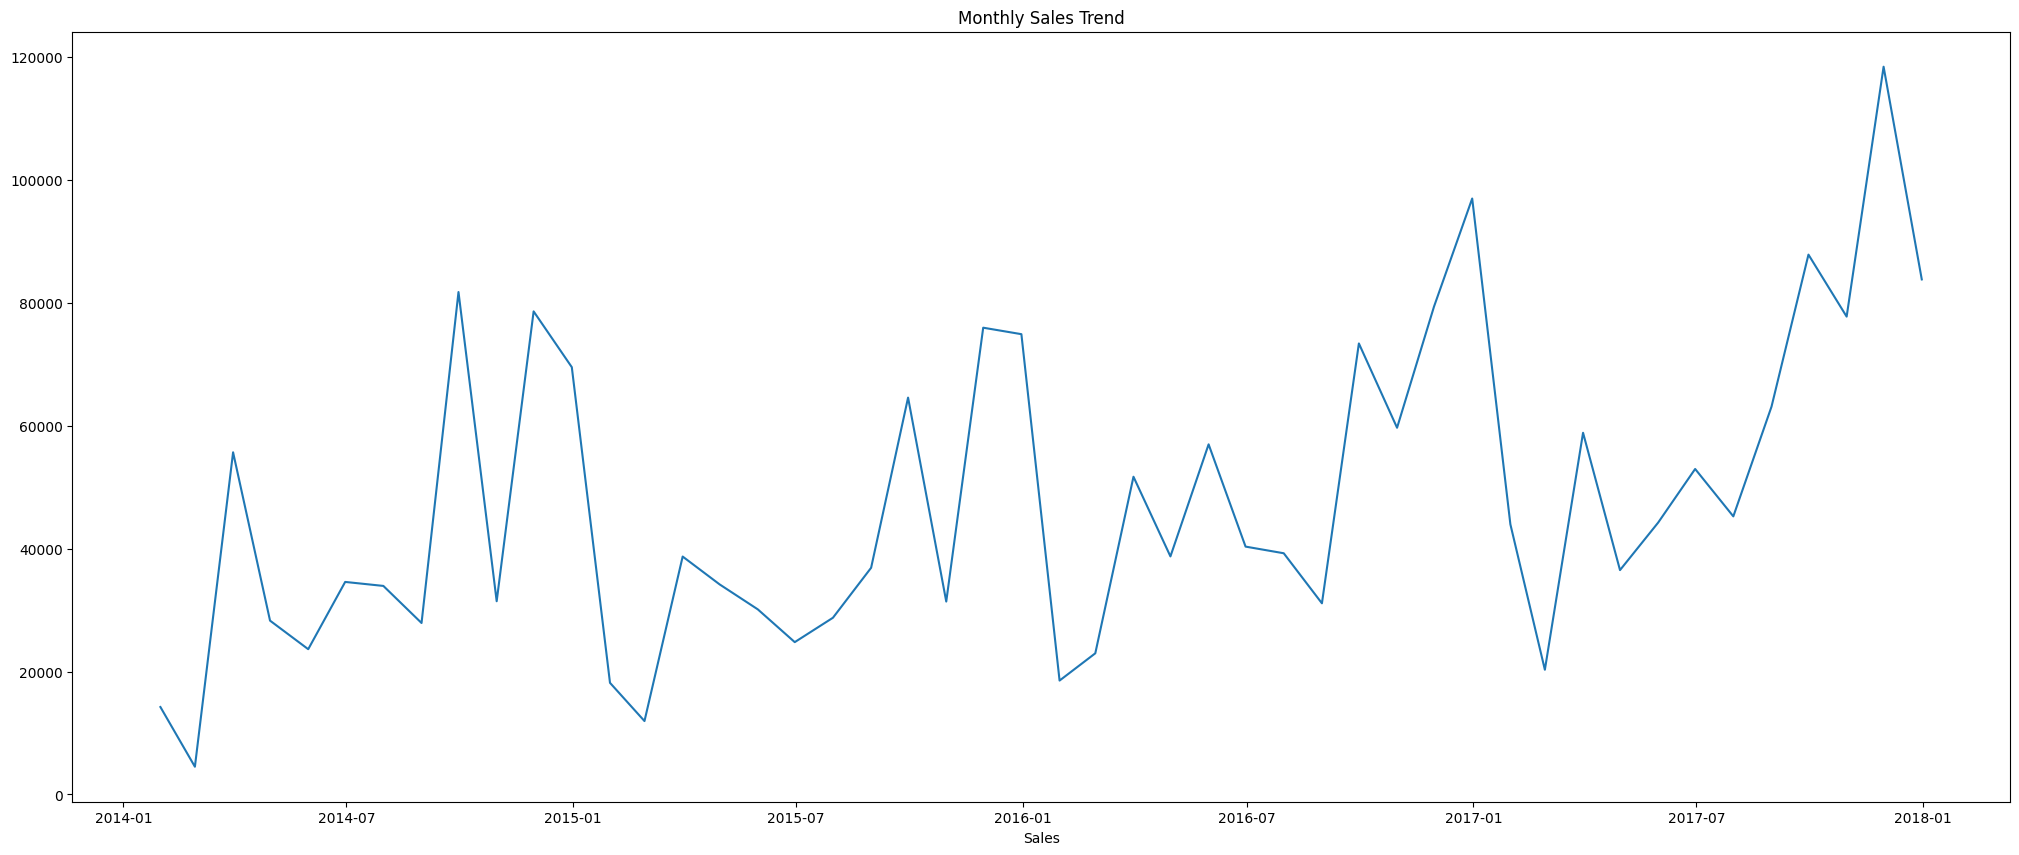

In [28]:
plt.figure(figsize=(25,10))
plt.plot(monthly_sales['Sales'])
plt.xlabel('Order Date')
plt.xlabel('Sales')
plt.title("Monthly Sales Trend")

Text(0.5, 1.0, 'Monthly Profit Trend')

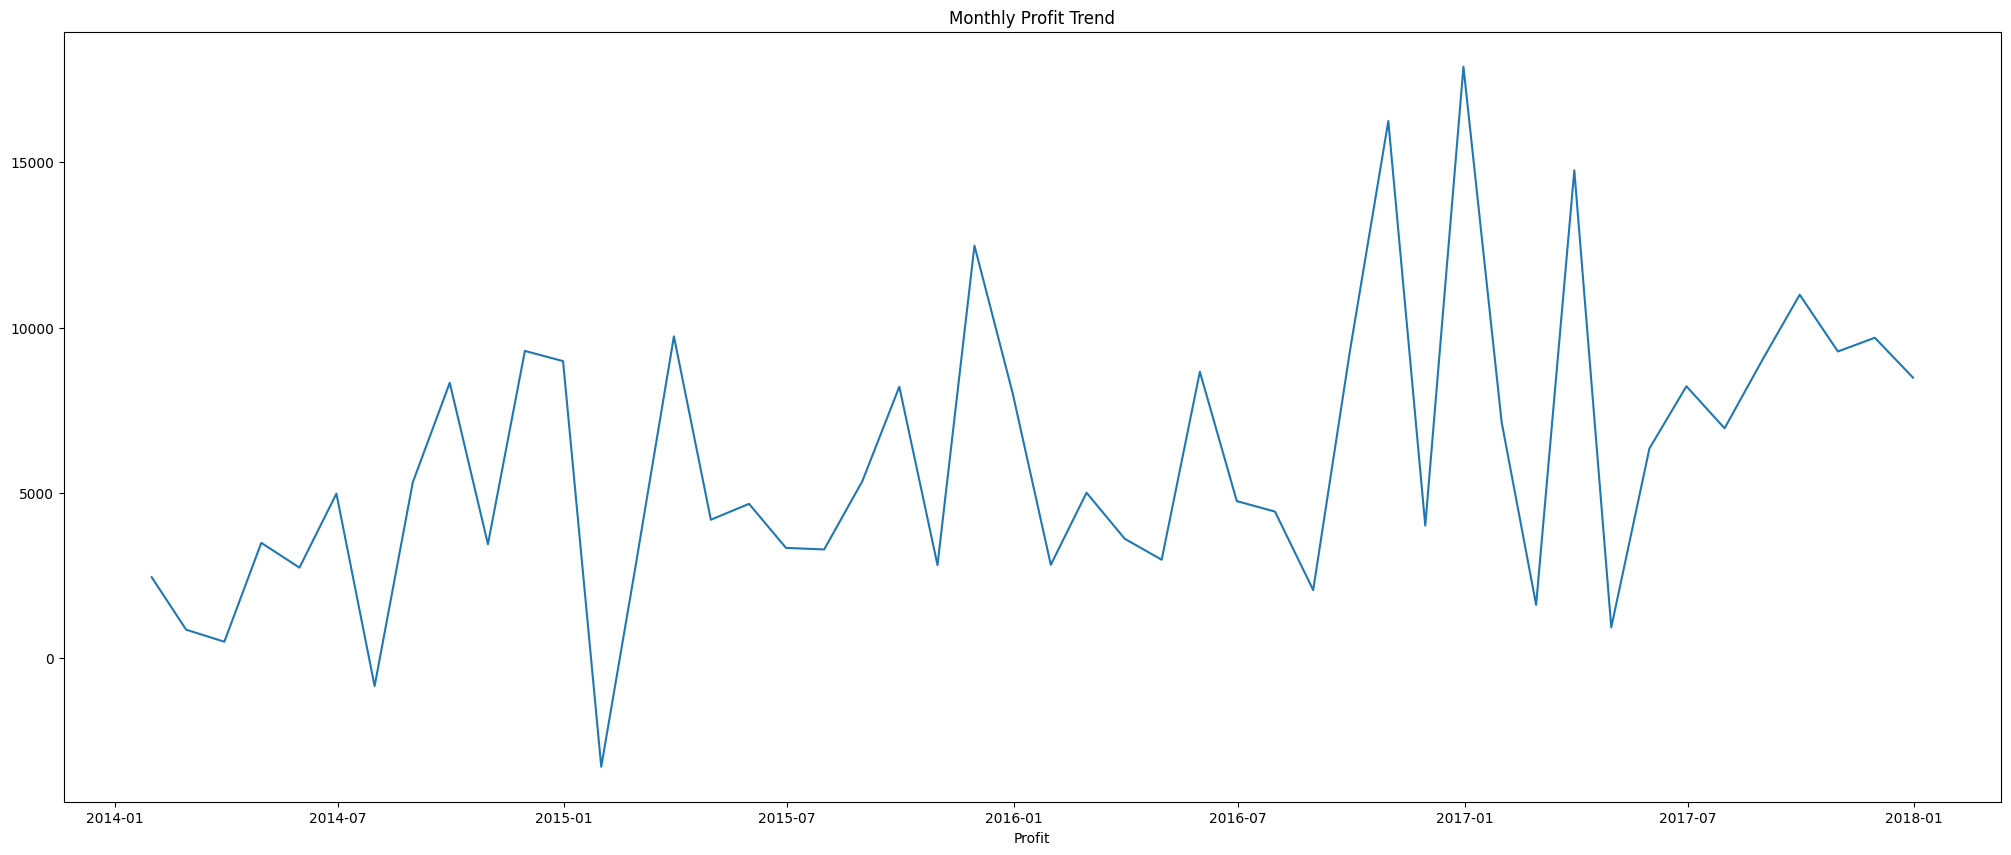

In [29]:
plt.figure(figsize=(25,10))
plt.plot(monthly_sales['Profit'])
plt.xlabel('Order Date')
plt.xlabel('Profit')
plt.title("Monthly Profit Trend")

In [30]:
yearly_sales = monthly_sales.resample('Y').sum()
yearly_sales 

,Row ID,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
Order Date,,,,,,,,,,,,,,,,,,,,
2014-12-31,9904015,CA-2014-103800CA-2014-112326CA-2014-112326CA-2...,1/7/20141/8/20141/8/20141/8/20141/12/20141/8/2...,Standard ClassStandard ClassStandard ClassStan...,DP-13000PO-19195PO-19195PO-19195MB-18085LS-172...,Darren PowersPhillina OberPhillina OberPhillin...,ConsumerHome OfficeHome OfficeHome OfficeConsu...,United StatesUnited StatesUnited StatesUnited ...,HoustonNapervilleNapervilleNapervillePhiladelp...,TexasIllinoisIllinoisIllinoisPennsylvaniaCalif...,113271247,CentralCentralCentralCentralEastWestSouthSouth...,OFF-PA-10000174OFF-LA-10003223OFF-ST-10002743O...,Office SuppliesOffice SuppliesOffice SuppliesO...,PaperLabelsStorageBindersArtPaperArtChairsBind...,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",484247.4981,7581,315.46,49543.9741
2015-12-31,10413696,CA-2015-146262CA-2015-146262CA-2015-146262CA-2...,1/9/20151/9/20151/9/20151/9/20151/9/20151/4/20...,Standard ClassStandard ClassStandard ClassStan...,VW-21775VW-21775VW-21775VW-21775VW-21775CB-125...,Victoria WilsonVictoria WilsonVictoria WilsonV...,CorporateCorporateCorporateCorporateCorporateC...,United StatesUnited StatesUnited StatesUnited ...,MedinaMedinaMedinaMedinaMedinaNewarkNewarkNewa...,OhioOhioOhioOhioOhioDelawareDelawareDelawareTe...,111208247,EastEastEastEastEastEastEastEastCentralCentral...,OFF-LA-10004544FUR-BO-10004695TEC-PH-10002844T...,Office SuppliesFurnitureTechnologyTechnologyTe...,LabelsBookcasesPhonesMachinesAccessoriesStorag...,Avery 505O'Sullivan 2-Door Barrister Bookcase ...,470532.5090,7979,327.09,61618.6037
2016-12-31,12778804,CA-2016-160304CA-2016-160304CA-2016-125206US-2...,1/7/20161/7/20161/5/20161/8/20161/8/20161/8/20...,Standard ClassStandard ClassFirst ClassStandar...,BM-11575BM-11575LR-16915CA-12310CA-12310CA-123...,Brendan MurryBrendan MurryLena RadfordChristin...,CorporateCorporateConsumerCorporateCorporateCo...,United StatesUnited StatesUnited StatesUnited ...,GaithersburgGaithersburgLos AngelesSan Antonio...,MarylandMarylandCaliforniaTexasTexasTexasOklah...,141003420,EastEastWestCentralCentralCentralCentralCentra...,FUR-BO-10004709TEC-PH-10000455OFF-ST-10003692T...,FurnitureTechnologyOffice SuppliesTechnologyTe...,BookcasesPhonesStorageAccessoriesAccessoriesPh...,"Bush Westfield Collection Bookcases, Medium Ch...",609205.5980,9837,400.32,81795.1743
2017-12-31,16848500,CA-2017-107503CA-2017-144463CA-2017-154466CA-2...,1/6/20171/5/20171/2/20171/5/20171/5/20171/5/20...,Standard ClassStandard ClassFirst ClassStandar...,GA-14725SC-20725DP-13390JM-15250JM-15250JM-152...,Guy ArmstrongSteven CartwrightDennis PardueJan...,ConsumerConsumerHome OfficeConsumerConsumerCon...,United StatesUnited StatesUnited StatesUnited ...,LorainLos AngelesFranklinHuntsvilleHuntsvilleH...,OhioCaliforniaWisconsinTexasTexasTexasTexasTex...,186089738,EastWestCentralCentralCentralCentralCentralCen...,FUR-FU-10003878FUR-FU-10001215OFF-BI-10002012O...,FurnitureFurnitureOffice SuppliesOffice Suppli...,FurnishingsFurnishingsBindersStorageFurnishing...,"Linden 10"" Round Wall Clock, BlackHoward Mille...",733215.2552,12476,518.22,93439.2696


Text(0.5, 1.0, 'yearly Sales Trend')

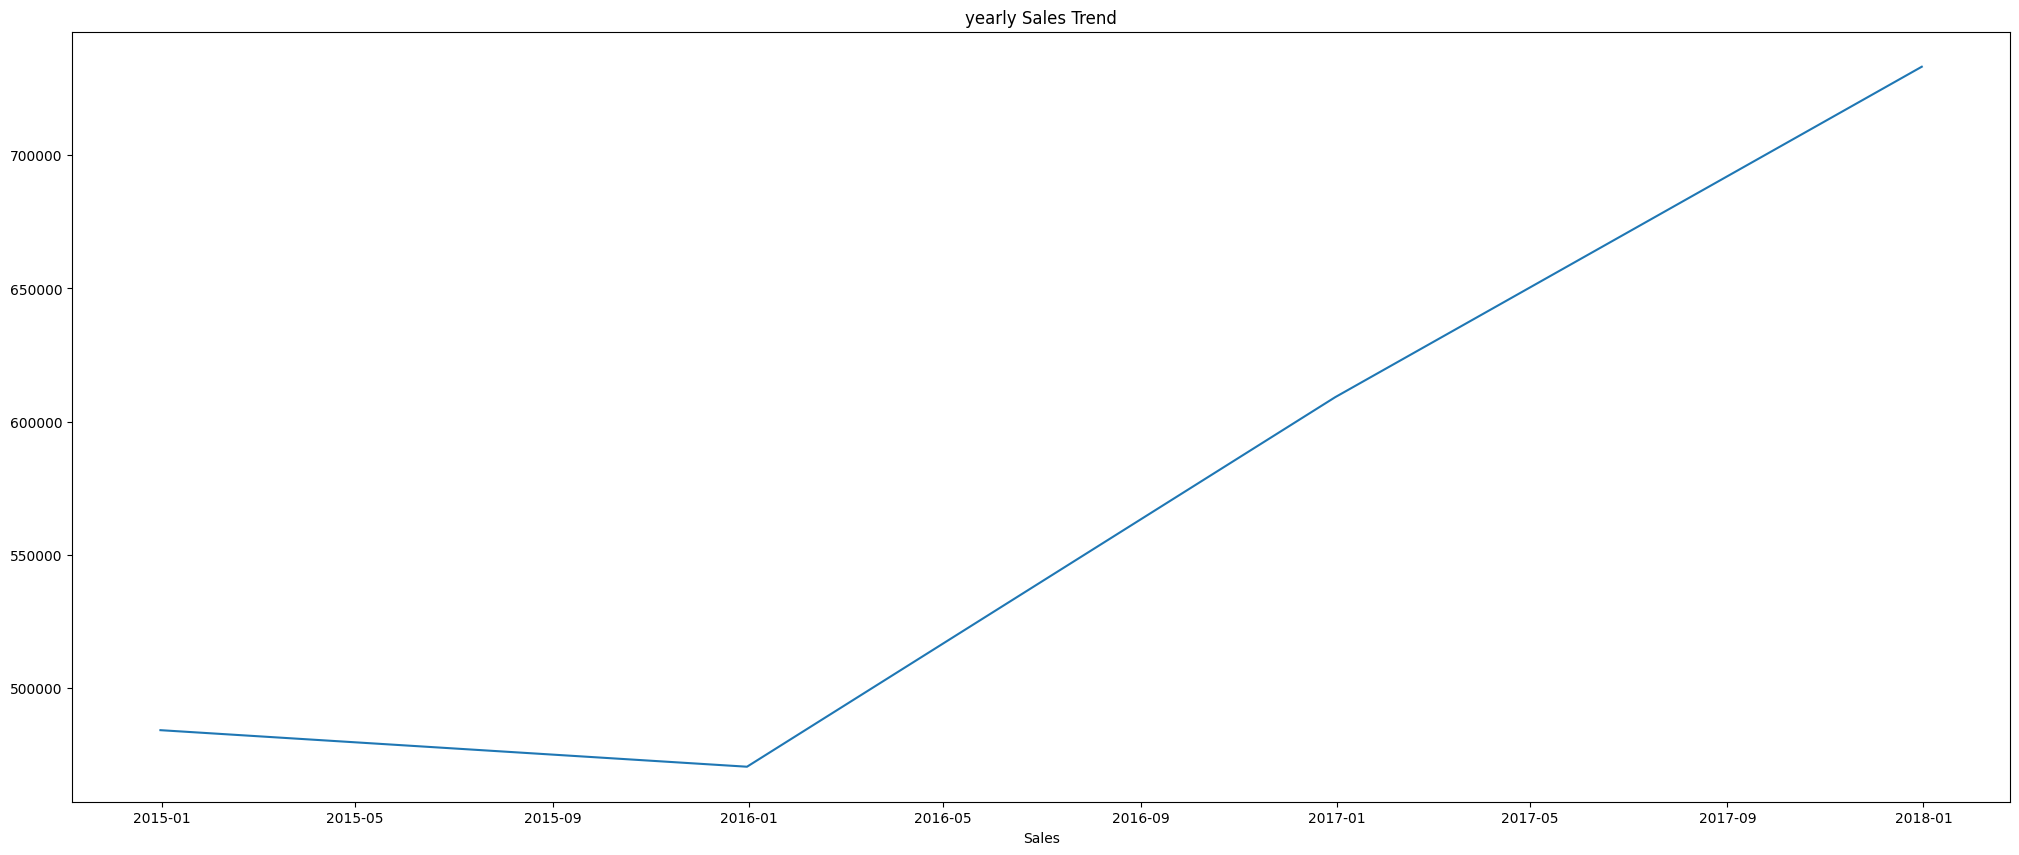

In [31]:
plt.figure(figsize=(25,10))
plt.plot(yearly_sales['Sales'])
plt.xlabel('Order Date')
plt.xlabel('Sales')
plt.title("yearly Sales Trend")

Text(0.5, 1.0, 'yearly Profit Trend')

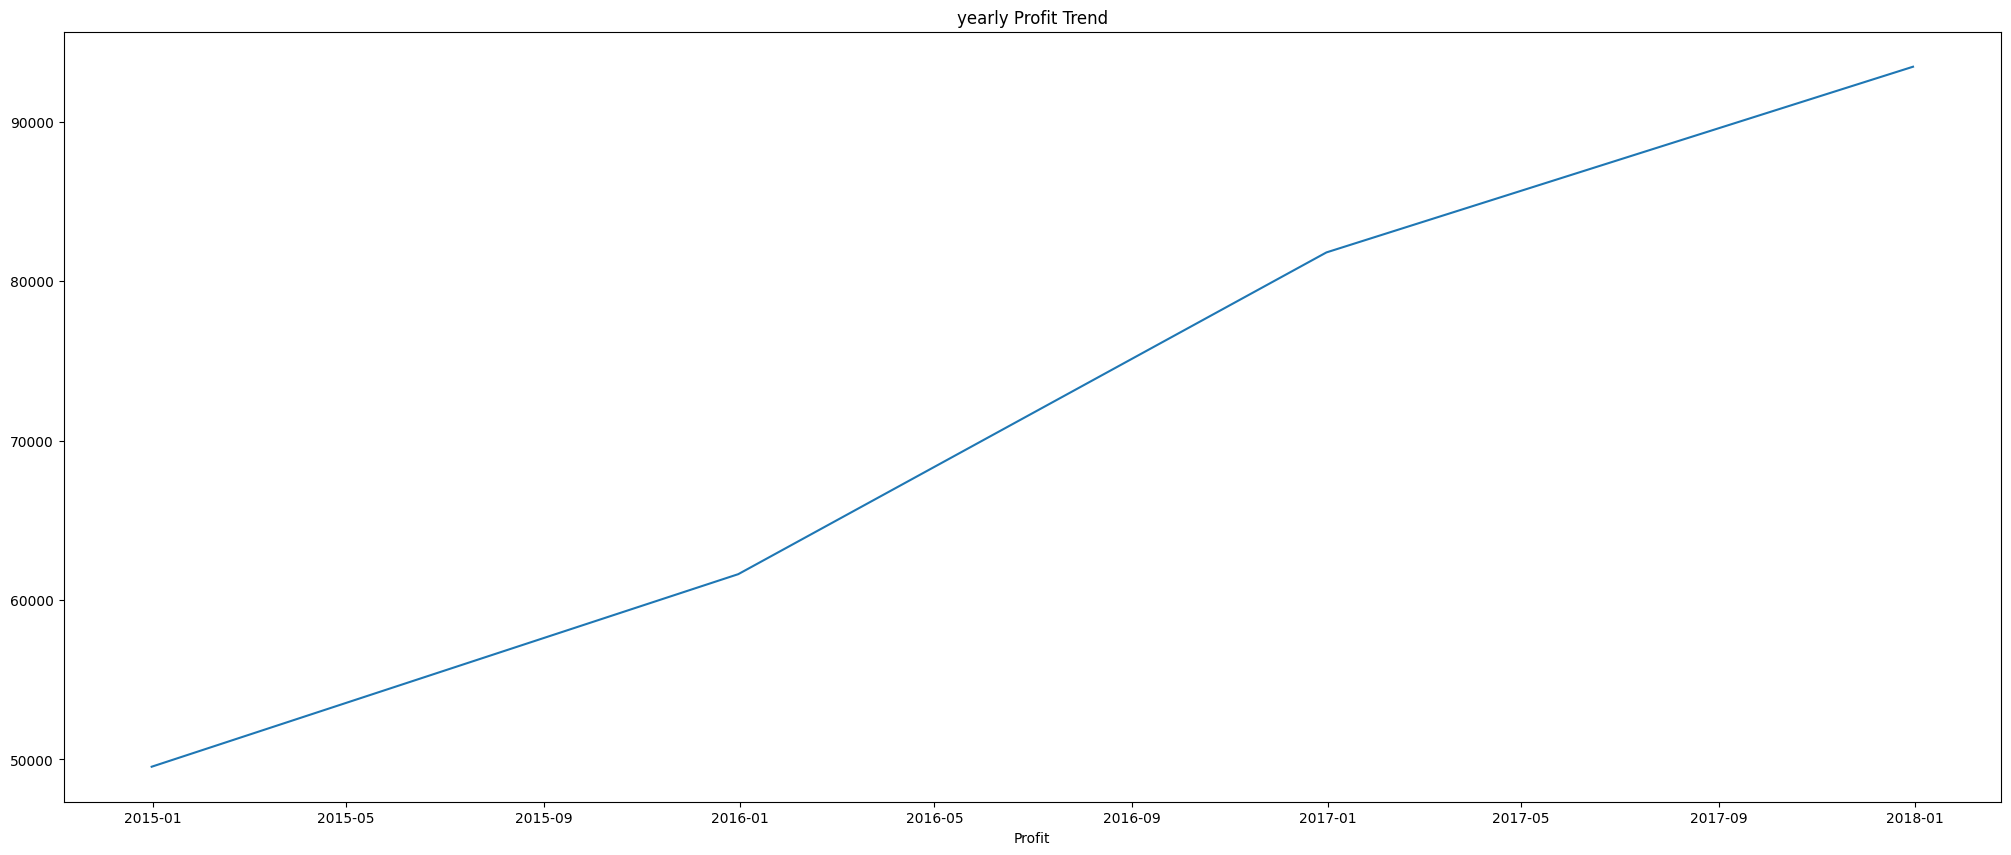

In [32]:
plt.figure(figsize=(25,10))
plt.plot(yearly_sales['Profit'])
plt.xlabel('Order Date')
plt.xlabel('Profit')
plt.title("yearly Profit Trend")

## Which region & place generates the most sales?

In [33]:
data_places=data[['Country','City','State','Region']]
data_places.head()

,Country,City,State,Region
0,United States,Henderson,Kentucky,South
1,United States,Henderson,Kentucky,South
2,United States,Los Angeles,California,West
3,United States,Fort Lauderdale,Florida,South
4,United States,Fort Lauderdale,Florida,South


In [34]:
for places in data_places.columns:
    print(f'{places}:{data_places[places].nunique()}')

Country:1
City:531
State:49
Region:4


In [35]:
data_places = data[['City','State','Region','Sales','Profit']]
data_places.head()

,City,State,Region,Sales,Profit
0,Henderson,Kentucky,South,261.9600,41.9136
1,Henderson,Kentucky,South,731.9400,219.5820
2,Los Angeles,California,West,14.6200,6.8714
3,Fort Lauderdale,Florida,South,957.5775,-383.0310
4,Fort Lauderdale,Florida,South,22.3680,2.5164


In [36]:
grouped_data=data_places.groupby('Region',as_index=False).sum()
grouped_data.sort_values(by='Sales', ascending=False, inplace=True)
grouped_data

,Region,City,State,Sales,Profit
3,West,Los AngelesLos AngelesLos AngelesLos AngelesLo...,CaliforniaCaliforniaCaliforniaCaliforniaCalifo...,725457.8245,108418.4489
1,East,PhiladelphiaPhiladelphiaPhiladelphiaPhiladelph...,PennsylvaniaPennsylvaniaPennsylvaniaPennsylvan...,678781.2400,91522.7800
0,Central,Fort WorthFort WorthMadisonFremontFremontHoust...,TexasTexasWisconsinNebraskaNebraskaTexasTexasT...,501239.8908,39706.3625
2,South,HendersonHendersonFort LauderdaleFort Lauderda...,KentuckyKentuckyFloridaFloridaNorth CarolinaFl...,391721.9050,46749.4303


In [37]:
grouped_data_state=data_places.groupby('State',as_index=False).sum()
grouped_data_state.sort_values(by='Sales', ascending=False, inplace=True)


In [38]:
grouped_data_City=data_places.groupby('City',as_index=False).sum()
grouped_data_City.sort_values(by='Sales', ascending=False, inplace=True)


Text(0.5, 1.0, 'Sales Generated by Region ')

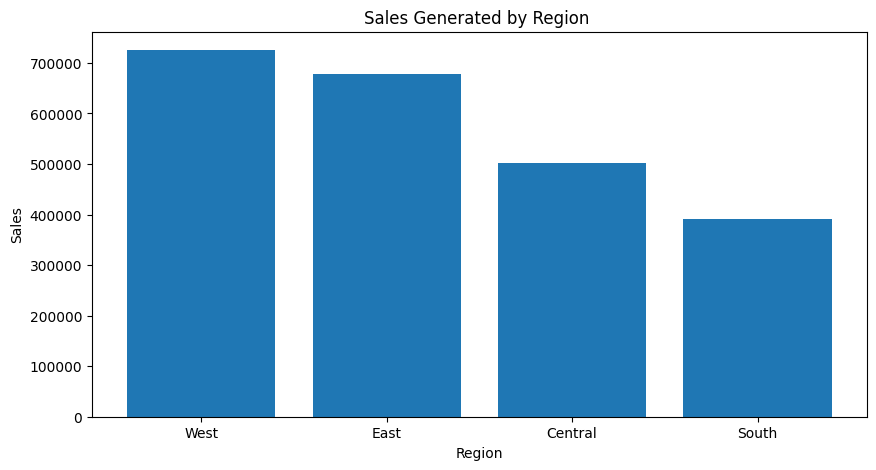

In [39]:

# Plot the total sales geProfitnerated by each region and city
plt.figure(figsize=(10,5))
plt.bar(grouped_data['Region'],grouped_data['Sales'])
plt.xlabel("Region")
plt.ylabel("Sales")
plt.title("Sales Generated by Region ")



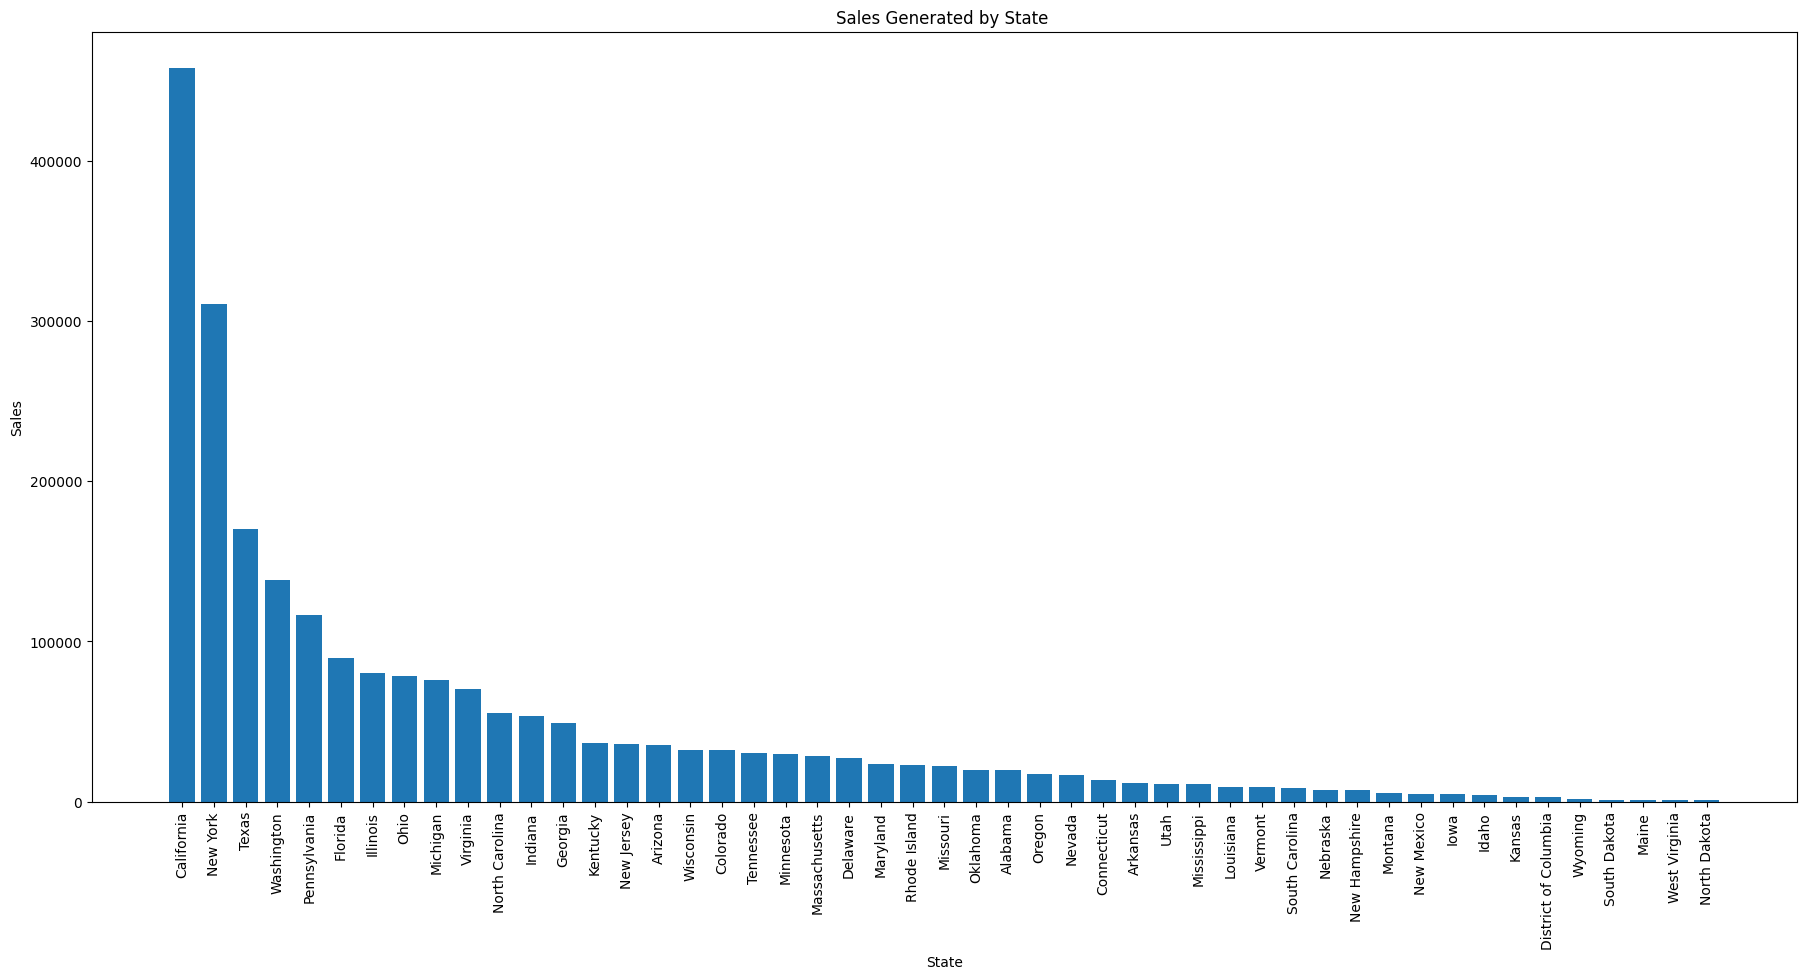

In [40]:

# Plot the total sales geProfitnerated by each region and city
plt.figure(figsize=(22,10))
plt.bar(grouped_data_state['State'],grouped_data_state['Sales'])
plt.xlabel("State")
plt.ylabel("Sales")
plt.title("Sales Generated by State ")
plt.xticks(rotation=90)
plt.show()

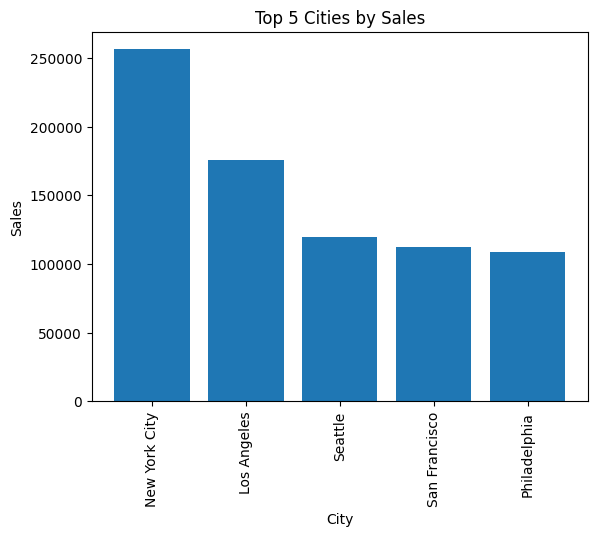

In [41]:
Top_5_City=grouped_data_City.head()
# Plot the total sales geProfitnerated by each region and city
plt.bar(Top_5_City['City'],Top_5_City['Sales'])
plt.xlabel("City")
plt.ylabel("Sales")
plt.title("Top 5 Cities by Sales")
plt.xticks(rotation=90)
plt.show()

## top sales places are :

**Cities**: [New York City, Los Angeles, Seattle, San Francisco, Philadelphia]

**State** : [california, New York]

**Region** : [West,East]

Text(0.5, 1.0, 'Profit Generated by Region')

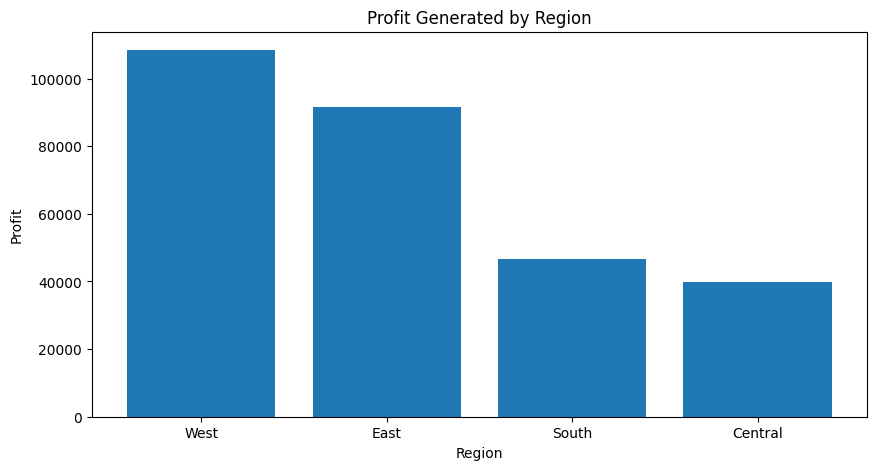

In [42]:
grouped_data.sort_values(by='Profit', ascending=False, inplace=True)
plt.figure(figsize=(10,5))
plt.bar(grouped_data['Region'], grouped_data['Profit'])
plt.xlabel("Region")
plt.ylabel("Profit")
plt.title("Profit Generated by Region")

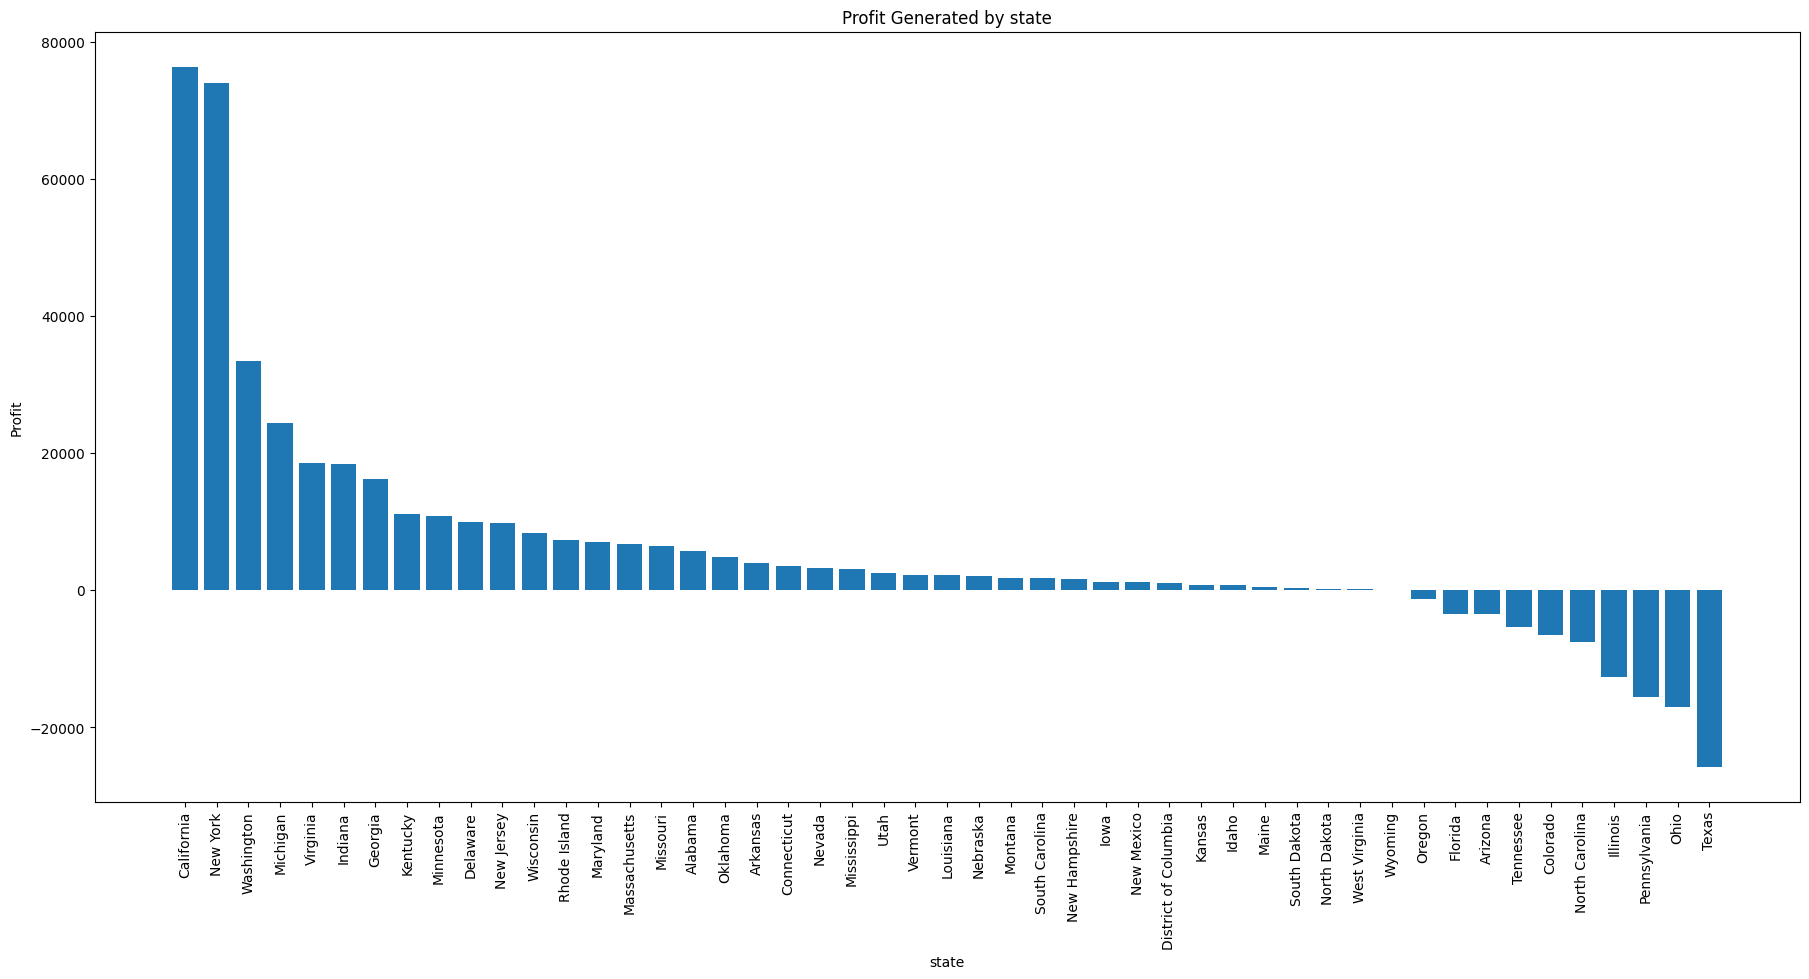

In [43]:
grouped_data_state.sort_values(by='Profit', ascending=False, inplace=True)
plt.figure(figsize=(22,10))
plt.bar(grouped_data_state['State'], grouped_data_state['Profit'])
plt.xlabel("state")
plt.ylabel("Profit")
plt.title("Profit Generated by state")
plt.xticks(rotation=90)
plt.show()

Text(0.5, 1.0, 'Top 5 Cities by Profit')

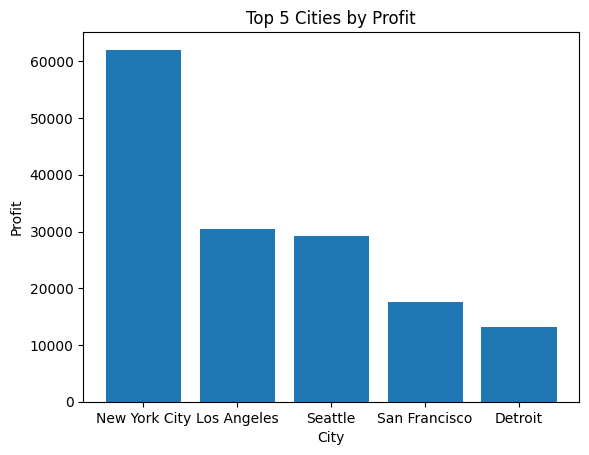

In [44]:
grouped_data_City.sort_values(by='Profit', ascending=False, inplace=True)
Top_5_Cities =grouped_data_City.head()
plt.bar(Top_5_Cities['City'], Top_5_Cities['Profit'])
plt.xlabel("City")
plt.ylabel("Profit")
plt.title("Top 5 Cities by Profit")

## top Profit places are :

**Cities**: [New York City, Los Angeles, Seattle, San Francisco, Detroit]

**State** : [california, New York]

**Region** : [West,East]

## What is the impact of discounts on sales?

In [45]:
data.Discount.value_counts()

Discount
0.00    4798
0.20    3657
0.70     418
0.80     300
0.30     227
0.40     206
0.60     138
0.10      94
0.50      66
0.15      52
0.32      27
0.45      11
Name: count, dtype: int64

In [46]:
discount_group=data.groupby('Discount')['Sales'].sum()

Text(0, 0.5, 'Sales')

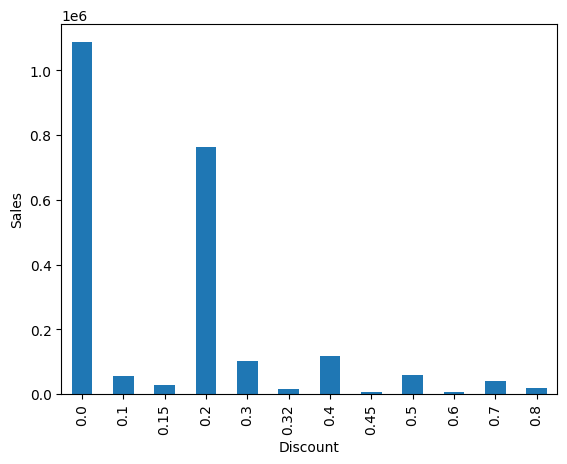

In [47]:
ax=discount_group.plot(kind='bar')
ax.set_ylabel("Sales")

Text(0, 0.5, 'Profit')

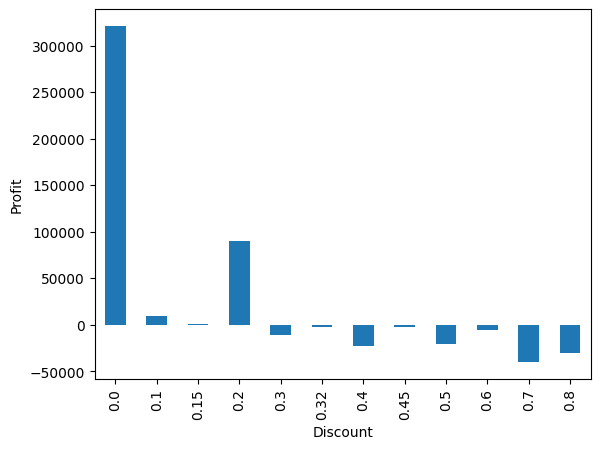

In [48]:
discount_group=data.groupby('Discount')['Profit'].sum()
ax=discount_group.plot(kind='bar')
ax.set_ylabel('Profit')

# the best salles 
The discount from 10 to 20%. Is the best solution, as they are the second and third best sellers and make profits

## What is the average profit margin for each product category?

In [49]:
# Group the data by product category and calculate the average profit for each category
avg_profit_by_category=data.groupby('Category')['Profit'].mean()

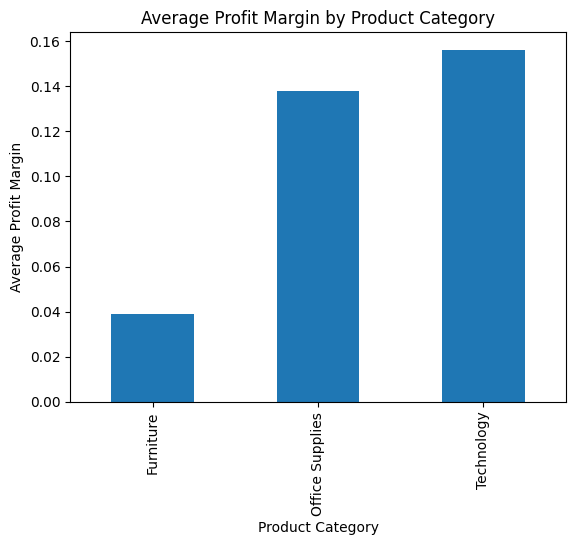

In [50]:
data['Profit Margin'] = data['Profit'] / data['Sales']

# Group the data by product category and calculate the average profit margin for each category
avg_profit_margin_by_category = data.groupby('Category')['Profit Margin'].mean()

avg_profit_margin_by_category.plot(kind='bar')
plt.title("Average Profit Margin by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Profit Margin")

plt.show()

In [51]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Profit Margin
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,0.1600
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,0.3000
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,0.4700
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,-0.4000
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,0.1125


In [52]:
data.groupby('Sub-Category')['Sales'].sum()

Sub-Category
Accessories    167380.3180
Appliances     107532.1610
Art             27118.7920
Binders        203412.7330
Bookcases      114879.9963
Chairs         328449.1030
Copiers        149528.0300
Envelopes       16476.4020
Fasteners        3024.2800
Furnishings     91705.1640
Labels          12486.3120
Machines       189238.6310
Paper           78479.2060
Phones         330007.0540
Storage        223843.6080
Supplies        46673.5380
Tables         206965.5320
Name: Sales, dtype: float64

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [5]:
df = pd.read_csv("../data/superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [7]:
df = df.sort_values('Order Date')

In [8]:
df = df[['Order Date', 'Sales']]
df.head()

,Order Date,Sales
7980,2014-01-03,16.448
739,2014-01-04,11.784
740,2014-01-04,272.736
741,2014-01-04,3.540
1759,2014-01-05,19.536


In [9]:
df = df.groupby('Order Date').sum().reset_index()
df.head()

,Order Date,Sales
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


In [10]:
df['time_index'] = range(len(df))
df.head()

,Order Date,Sales,time_index
0,2014-01-03,16.448,0
1,2014-01-04,288.060,1
2,2014-01-05,19.536,2
3,2014-01-06,4407.100,3
4,2014-01-07,87.158,4


In [11]:
X = df[['time_index']]
y = df['Sales']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.93]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['time_index']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1254
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [14]:
y_pred = model.predict(X_test)

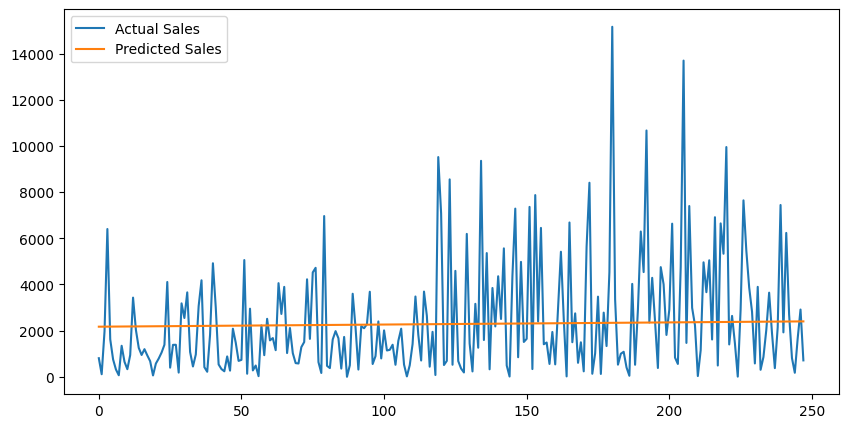

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual Sales")
plt.plot(y_pred, label="Predicted Sales")
plt.legend()
plt.show()

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)

MAE: 1797.5054227377636
MSE: 6019622.603158251


This model forecasts future sales using historical patterns.
It helps businesses plan inventory, manage stock levels, and reduce overstock or shortage risks.

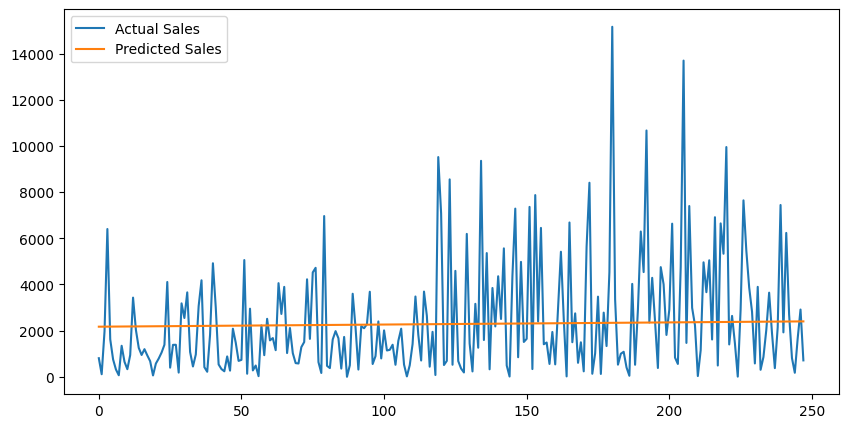

In [21]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual Sales")
plt.plot(y_pred, label="Predicted Sales")
plt.legend()

plt.savefig("outputs/forecast_result.png")
plt.show()

In [19]:
import os
os.makedirs("outputs", exist_ok=True)